In [1]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

local_address = "gros-91.nancy.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

### Experiment 1a

In [ ]:
experiments = {
    'rocks': {
        'start': dt.datetime(2025, 7, 15, 14, 41, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 15, 14, 50, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 15, 15, 0, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 15, 15, 10, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 15, 15, 17, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 15, 15, 25, 0, tzinfo=local_tz)
    }
}

metric_query = 'sum(flink_taskmanager_job_task_numRecordsOutPerSecond{component="taskmanager"})'
step = "5s"
output_filename = 'exp1a_max_tput.csv'

tput_series = []

print("\nBeginning request execution...")
for label, config in experiments.items():    
    df_metric = p.query_range(
        query=metric_query,
        start=config['start'].isoformat(),
        end=config['end'].isoformat(),
        step=step
    )

    if not df_metric.empty:
        tput_series.append(df_metric['{}'].rename("Throughput: " + label))

if tput_series:

    combined_df = pd.concat(tput_series, axis=1)

    combined_df.to_csv(output_filename, index_label='Time')
    
    print(f"\nFile saved : '{output_filename}'")
    
    plt.figure(figsize=(10, 7))
    combined_df.boxplot(axis='y', linestyle='--', alpha=0.7)
    plt.title('Max Throughput per configuration')
    plt.ylabel('TPUT (events/second)')
    plt.xlabel('Configuration')
    plt.show()

else:
    print("\nRequest Error")

### Rocks

In [ ]:
min_date = date.datetime(2025, 7, 15, 14, 41, 0, tzinfo=local_tz)
max_date = date.datetime(2025, 7, 15, 14, 50, 0, tzinfo=local_tz)
metric_query = 'sum(flink_taskmanager_job_task_numRecordsOutPerSecond{component="taskmanager"})'
step = "5s"
min_date_param = min_date.replace(microsecond=0).isoformat()
max_date_param = max_date.replace(microsecond=0).isoformat()
print ("Begin: " + min_date_param + " - End: " + max_date_param)

df_metric = p.query_range(
    metric_query,
    start=min_date_param, 
    end=max_date_param,
    step=step
)

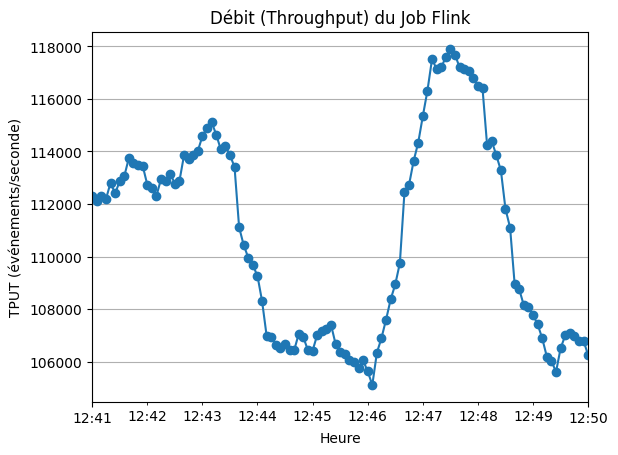

In [125]:
ax = df_metric.plot(
        title='Débit (Throughput) du Job Flink',
        marker='o',
        linestyle='-',
        grid=True,
        legend=False # La légende est inutile ici car il n'y a qu'une seule ligne
    )
    
    # On utilise l'objet "ax" pour configurer les labels
ax.set_xlabel('Heure')
ax.set_ylabel('TPUT (événements/seconde)')

    # Affiche le graphique
plt.show()

### CSV

In [111]:
df_metric.rename(columns={'{}': 'Throughput'}, inplace=True)
file_name = 'exp1_a_rocks.csv'
df_metric.to_csv(file_name, index_label='Time')

Lecture des fichiers CSV...
- Fichier 'exp1_a_rocks.csv' lu avec succès.
- Fichier 'exp1_a_forst.csv' lu avec succès.
- Fichier 'exp1_a_forst_w_cache.csv' lu avec succès.


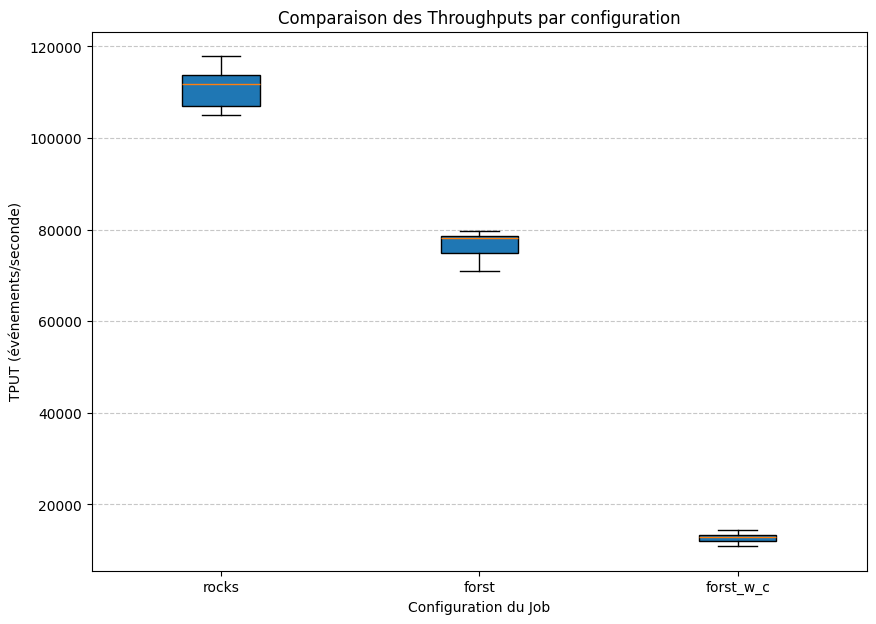

In [127]:
files_and_labels = {
    'exp1_a_rocks.csv': 'rocks',
    'exp1_a_forst.csv': 'forst',
    'exp1_a_forst_w_cache.csv': 'forst_w_c'
}

# Liste pour stocker les données de throughput de chaque fichier
throughput_data = []
# Liste pour les labels de l'axe X
x_labels = []

print("Lecture des fichiers CSV...")
for file_name, label in files_and_labels.items():
    try:
        # Lire le fichier CSV. La première colonne est l'index.
        df = pd.read_csv(file_name, index_col=0)
        throughput_data.append(df['Throughput'])
        x_labels.append(label)
        print(f"- Fichier '{file_name}' lu avec succès.")
        
    except FileNotFoundError:
        print(f"- ERREUR: Le fichier '{file_name}' est introuvable. Assurez-vous qu'il est dans le bon répertoire.")
    except KeyError:
        print(f"- ERREUR: La colonne 'Throughput' n'a pas été trouvée dans '{file_name}'.")

# --- 2. Création du Box Plot ---
if throughput_data:
    plt.figure(figsize=(10, 7)) # Crée une figure de bonne taille
    
    # Crée le box plot à partir de la liste de données
    plt.boxplot(throughput_data, tick_labels=x_labels, patch_artist=True)
    
    # Ajout des titres et des légendes
    plt.title('Comparaison des Throughputs par configuration')
    plt.ylabel('TPUT (événements/seconde)')
    plt.xlabel('Configuration du Job')
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Ajoute une grille horizontale

    # Affiche le graphique
    plt.show()
else:
    print("\\nAucune donnée à afficher. Veuillez vérifier les erreurs ci-dessus.")